https://github.com/ilya-shenbin/RecVAE

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import InputLayer, Dense, LayerNormalization, LeakyReLU, Dropout
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
from keras.layers import Input, Embedding, Flatten, Dot, Dense, Concatenate, BatchNormalization, Dropout
from keras.models import Model
from keras import backend as K
import os
import keras
# from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
# load data
from google.colab import drive
drive.mount('/content/drive')
path_final_processed_data = '/content/drive/MyDrive/final_processed_data.csv'

df = pd.read_csv(path_final_processed_data)
df.drop(columns='Unnamed: 0', inplace=True)

Mounted at /content/drive


In [ ]:
# normalize
min_rating = df['User Rating'].min()
max_rating = df['User Rating'].max()

df['Rating Normalize'] = (df['User Rating'] - min_rating) / (max_rating - min_rating)

print(f"Minimum of normalized User Rating: {df['Rating Normalize'].min()}")
print(f"Maximum of normalized User Rating: {df['Rating Normalize'].max()}")

Minimum of normalized User Rating: 0.0
Maximum of normalized User Rating: 1.0


In [ ]:
df

,Restaurant Name,Cuisine Type,Restaurant Rating,Location,Price,Username,User Rating,User Review,Rating Normalize
0,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,micky_ardhienoor_husin,4.8,One of my bucket list\nPenasaran pgn makan di ...,0.95
1,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,rebecca_t,4.8,One of the Best Japanese Hotpot\nKayaknya Momo...,0.95
2,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,foodbuddies.id,4.8,The Best Authentic Japanese Sukiyaki & Shabu-S...,0.95
3,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,antihungryclub,5.0,AYCE Authentic khas Jepang\nMomo Paradise -- T...,1.00
4,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,fitriahlaela,5.0,AYCE yg worth it!!\nAYCE yang menyenangkan dan...,1.00
...,...,...,...,...,...,...,...,...,...
28146,Anomali Coffee,Kafe,4.46,Menteng,Rp. 50.000 - Rp. 100.000 /orang,Tissa789,3.0,Starbucks versi Indonesia\nAnomali tuh menurut...,0.50
28147,Anomali Coffee,Kafe,4.46,Menteng,Rp. 50.000 - Rp. 100.000 /orang,si_zel,4.4,Tempat hang out favorit\nLokasinya yang cukup ...,0.85
28148,Anomali Coffee,Kafe,4.46,Menteng,Rp. 50.000 - Rp. 100.000 /orang,Ilma,5.0,"konsepnya asik!\nBegitu masuk, kalian akan lia...",1.00
28149,Anomali Coffee,Kafe,4.46,Menteng,Rp. 50.000 - Rp. 100.000 /orang,UrsAndNic,4.0,"Homey Coffee shop\nSuka banget ambiencenya,ter...",0.75


In [ ]:
rating_data_df = df[['Username', 'Restaurant Name', 'Rating Normalize']].copy()

user_encoder = LabelEncoder()
resto_encoder = LabelEncoder()

rating_data_df['User_Id'] = user_encoder.fit_transform(rating_data_df['Username'])
rating_data_df['Place_Id'] = resto_encoder.fit_transform(rating_data_df['Restaurant Name'])

rating_data_df = rating_data_df[['User_Id', 'Place_Id', 'Rating Normalize']]

In [ ]:
rating_data_df

,User_Id,Place_Id,Rating Normalize
0,2287,615,0.95
1,2672,615,0.95
2,1507,615,0.95
3,712,615,1.00
4,1497,615,1.00
...,...,...,...
28146,375,41,0.50
28147,2936,41,0.85
28148,160,41,1.00
28149,381,41,0.75


In [ ]:
# X_trainval, X_test = train_test_split(rating_data_df, test_size=0.2, random_state=42)
# X_train, X_val = train_test_split(X_trainval, test_size=0.125, random_state=42) # val : 0.1 dari train

-------

# VAE

In [ ]:
# Create user-item matrix
df_copy = rating_data_df.drop_duplicates(subset=["User_Id", "Place_Id"])
user_item_matrix = df_copy.pivot(index="User_Id", columns="Place_Id", values="Rating Normalize")
user_item_matrix = user_item_matrix.fillna(0)

print(f"User-Item Matrix Shape: {user_item_matrix.shape}")

User-Item Matrix Shape: (3382, 1046)


In [ ]:
X = user_item_matrix.values # user vector

X_trainval, X_test = train_test_split(X, test_size=0.2, random_state=42)
X_train, X_val = train_test_split(X_trainval, test_size=0.125, random_state=42) # val : 0.1 dari train

X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
X_test = tf.convert_to_tensor(X_test, dtype=tf.float32)
X_val = tf.convert_to_tensor(X_val, dtype=tf.float32)

In [ ]:
original_X_train = X_train * (max_rating - min_rating) + min_rating
original_X_val = X_val * (max_rating - min_rating) + min_rating

In [ ]:
input_size = X_train.shape[1]
hidden_dim = 200
latent_dim = 100
batch_size = 200
epochs = 100
device = "cuda" if tf.config.list_physical_devices('GPU') else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [ ]:
class VAE(tf.keras.Model):
    def __init__(self, h_dim, l_dim, input_size, **kwargs):
        """
            h_dim (int): Dimension of the hidden layer in encoder/decoder.
            l_dim (int): Dimension of the latent space (mu and log_var).
            input_size (int): The dimension of the input data (number of items).
            **kwargs: Arbitrary keyword arguments passed to the Keras Model base class.
        """
        super(VAE, self).__init__(**kwargs)
        self.h_dim = h_dim
        self.l_dim = l_dim
        self.input_size = input_size

        # Encoder: Maps input features to a hidden representation
        self.encoder = tf.keras.Sequential([
            InputLayer(shape=(input_size,)),
            Dense(50),
            LayerNormalization(epsilon=1e-1), # konsisten e
            LeakyReLU(),
            Dense(h_dim, activation='relu')
        ], name="encoder")

        # Latent space parameters: mu (mean) and log_var (log variance)
        self.mu = Dense(l_dim, name="mu_layer")
        self.log_var = Dense(l_dim, name="log_var_layer")

        # Decoder: Maps from the latent space back to the original input dimension.
        self.decoder = tf.keras.Sequential([
            Dense(h_dim, activation='relu'), # Start with a dense layer
            LayerNormalization(epsilon=1e-1),
            LeakyReLU(),
            Dense(input_size) # Outputs raw logits in the original input_size dimension, suitable for tf.nn.sigmoid_cross_entropy_with_logits in loss calculation
            # No activation on the final Dense layer
        ], name="decoder")

    def build(self, input_shape):
        self.encoder.build(input_shape)
        # input for mu and log_var = output of encoder
        self.mu.build(self.encoder.output_shape)
        self.log_var.build(self.encoder.output_shape)
        # input for decoder = latent dimension (l_dim)
        self.decoder.build((None, self.l_dim)) # (None, l_dim), batch size unknown
        super().build(input_shape)

    def encode(self, x):
      # encode input x to latent space
        h = self.encoder(x)
        return self.mu(h), self.log_var(h)

    def reparametrize(self, mu, log_var):
      # reparameterization trick : sample from latent distribution
        std = tf.exp(log_var * 0.5)
        sample = tf.random.normal(tf.shape(std))
        return mu + sample * std

    def decode(self, l):
        """
        Decodes a latent space sample 'l' back into the original input space (as logits).
        This method now directly calls the decoder and returns its raw output (logits).
        """
        return self.decoder(l)

    def call(self, inputs, training=None, mask=None):
        # Encode the input
        mu, log_var = self.encode(inputs)
        # Reparameterize to get a sample from the latent space
        latent = self.reparametrize(mu, log_var)
        # Decode the latent sample back to the input space (as logits)
        reconstructed_logits = self.decode(latent)
        return reconstructed_logits, mu, log_var


In [ ]:
model = VAE(h_dim=hidden_dim, l_dim=latent_dim, input_size=input_size)
model.build(input_shape=(None, input_size))
model.summary()

Model: "vae_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 200)            │        62,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mu_layer (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_var_layer (Dense)           │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 1046)           │       230,846 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,696 (1.27 MB)

 Trainable params: 333,696 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices(X_train)
dataset = dataset.shuffle(buffer_size=X_train.shape[0]).batch(batch_size) # Use X_train.shape[0] for buffer_size
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

recons_loss_history = []
kldiv_history = []
loss_history = []

In [ ]:
def compute_rmse_mae(X_true, X_pred):
    mask = tf.cast(X_true > 0, tf.bool)
    true_ratings = tf.boolean_mask(X_true, mask)
    pred_ratings = tf.boolean_mask(X_pred, mask)
    rmse = tf.sqrt(tf.reduce_mean(tf.square(true_ratings - pred_ratings)))
    mae = tf.reduce_mean(tf.abs(true_ratings - pred_ratings))
    return rmse.numpy(), mae.numpy()

In [ ]:
# Training loop
patience = 5
best_val_rmse = float('inf')
best_val_mae = float('inf')

epochs_without_improvement = 0
best_weights = None

train_rmse_per_epoch = []
val_rmse_per_epoch = []
train_mae_per_epoch = []
val_mae_per_epoch = []

for epoch in range(epochs):
    for x_batch in dataset:
        with tf.GradientTape() as tape:
            x_recon, mu, log_var = model(x_batch)
            recon_loss = tf.nn.sigmoid_cross_entropy_with_logits(labels=x_batch, logits=x_recon)
            recon_loss = tf.reduce_sum(recon_loss) / batch_size
            kl_div = -0.5 * tf.reduce_mean(1 + log_var - tf.square(mu) - tf.exp(log_var))
            loss = recon_loss + kl_div
        grads = tape.gradient(loss, model.trainable_variables)
        grads = [tf.clip_by_norm(g, 5.0) for g in grads]
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

    # Predict
    train_pred = tf.nn.sigmoid(model(X_train)[0]) * (max_rating - min_rating) + min_rating
    val_pred = tf.nn.sigmoid(model(X_val)[0]) * (max_rating - min_rating) + min_rating
    rmse_train, mae_train = compute_rmse_mae(original_X_train, train_pred)
    rmse_val, mae_val = compute_rmse_mae(original_X_val, val_pred)

    train_rmse_per_epoch.append(rmse_train)
    val_rmse_per_epoch.append(rmse_val)
    train_mae_per_epoch.append(mae_train)
    val_mae_per_epoch.append(mae_val)

    print(f"Epoch {epoch+1:02d}: RMSE - Train: {rmse_train:.4f}, Val: {rmse_val:.4f} | MAE - Train: {mae_train:.4f}, Val: {mae_val:.4f}")

    # EARLY STOPPING
    if (rmse_val < best_val_rmse) or (mae_val < best_val_mae):
        if rmse_val < best_val_rmse:
            best_val_rmse = rmse_val
        if mae_val < best_val_mae:
            best_val_mae = mae_val
        epochs_without_improvement = 0
        best_weights = model.get_weights()
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"⏹️ Early stopping at epoch {epoch+1} (Neither RMSE nor MAE improved for {patience} epochs)")
            model.set_weights(best_weights)
            break


Epoch 01: RMSE - Train: 1.9763, Val: 1.9777 | MAE - Train: 1.9353, Val: 1.9373
Epoch 02: RMSE - Train: 1.9222, Val: 1.9229 | MAE - Train: 1.8804, Val: 1.8814
Epoch 03: RMSE - Train: 1.8675, Val: 1.8681 | MAE - Train: 1.8250, Val: 1.8257
Epoch 04: RMSE - Train: 1.8122, Val: 1.8131 | MAE - Train: 1.7687, Val: 1.7697
Epoch 05: RMSE - Train: 1.7562, Val: 1.7570 | MAE - Train: 1.7116, Val: 1.7126
Epoch 06: RMSE - Train: 1.6958, Val: 1.6955 | MAE - Train: 1.6499, Val: 1.6495
Epoch 07: RMSE - Train: 1.6340, Val: 1.6359 | MAE - Train: 1.5867, Val: 1.5886
Epoch 08: RMSE - Train: 1.5681, Val: 1.5713 | MAE - Train: 1.5192, Val: 1.5228
Epoch 09: RMSE - Train: 1.4997, Val: 1.5031 | MAE - Train: 1.4491, Val: 1.4529
Epoch 10: RMSE - Train: 1.4241, Val: 1.4269 | MAE - Train: 1.3716, Val: 1.3748
Epoch 11: RMSE - Train: 1.3432, Val: 1.3501 | MAE - Train: 1.2890, Val: 1.2964
Epoch 12: RMSE - Train: 1.2528, Val: 1.2567 | MAE - Train: 1.1966, Val: 1.2012
Epoch 13: RMSE - Train: 1.1570, Val: 1.1575 | MAE - 

epoch 100\
rmse train : \
rmse val : \
mae train : \
mae val :

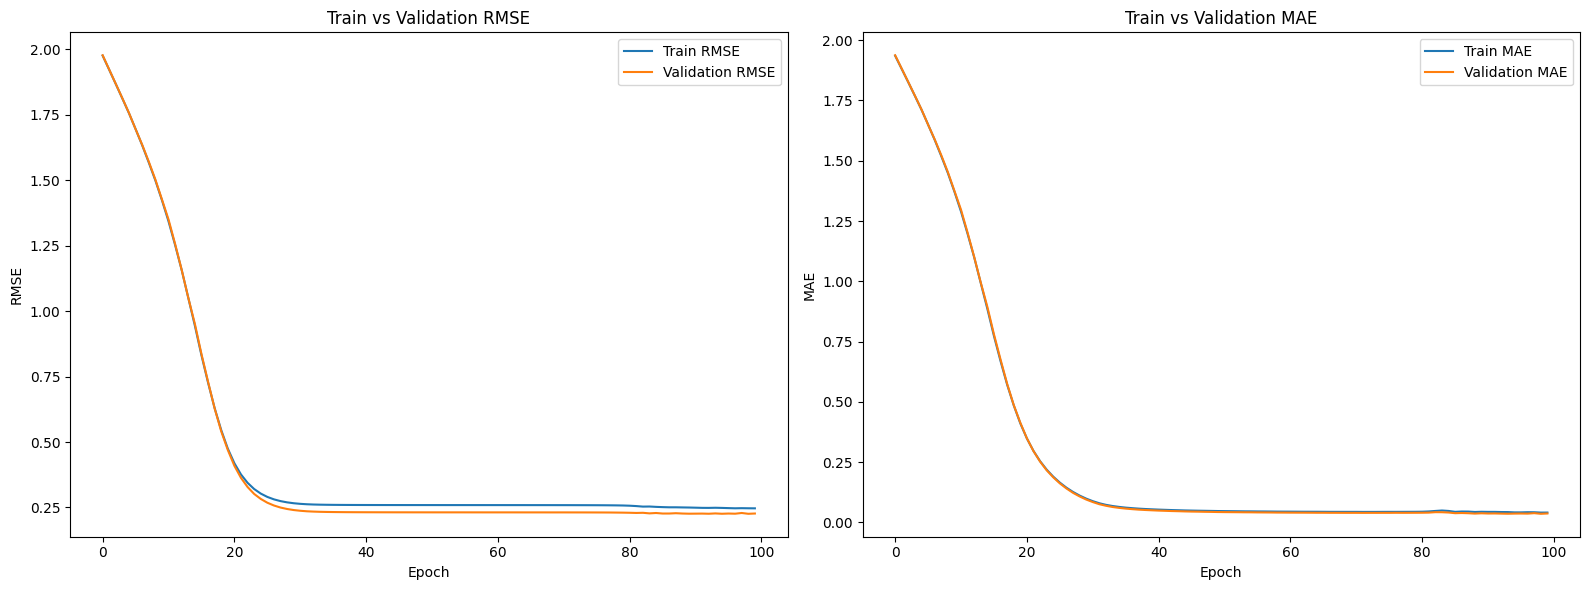

In [ ]:

# Plot loss curve
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(train_rmse_per_epoch, label='Train RMSE')
plt.plot(val_rmse_per_epoch, label='Validation RMSE')
plt.title('Train vs Validation RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_mae_per_epoch, label='Train MAE')
plt.plot(val_mae_per_epoch, label='Validation MAE')
plt.title('Train vs Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

Epoch 30: \
RMSE - Train: 0.2657, Val: 0.2396 | \
MAE - Train: 0.0976, Val: 0.0937



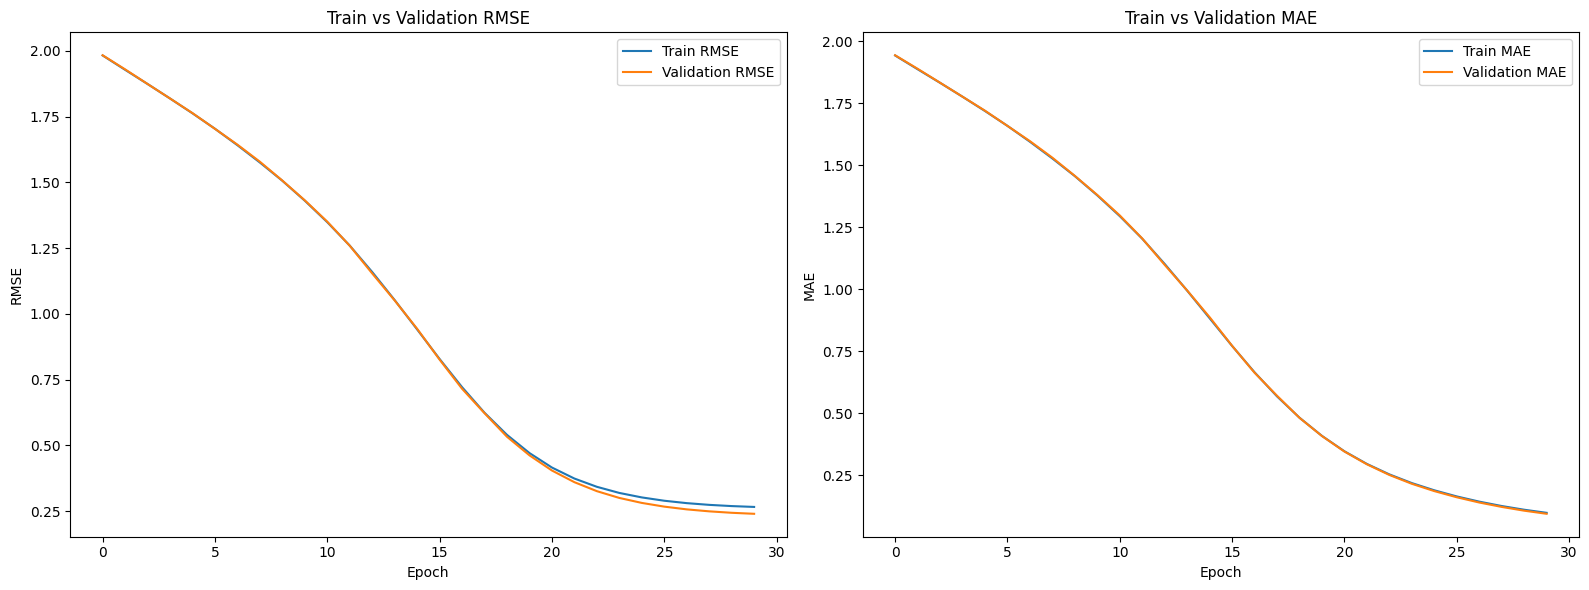

In [ ]:

# Plot loss curve
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(train_rmse_per_epoch, label='Train RMSE')
plt.plot(val_rmse_per_epoch, label='Validation RMSE')
plt.title('Train vs Validation RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_mae_per_epoch, label='Train MAE')
plt.plot(val_mae_per_epoch, label='Validation MAE')
plt.title('Train vs Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
test_logits, _, _ = model(X_test)
test_pred_norm = tf.nn.sigmoid(test_logits)
test_pred = test_pred_norm * (max_rating - min_rating) + min_rating

In [ ]:
original_X_test = X_test * (max_rating - min_rating) + min_rating

In [ ]:
rmse_test, mae_test = compute_rmse_mae(original_X_test, test_pred)
print(f"Test RMSE: {rmse_test:.4f}")
print(f"Test MAE : {mae_test:.4f}")

Test RMSE: 0.2556
Test MAE : 0.0430


In [ ]:
rmse_test, mae_test = compute_rmse_mae(original_X_test, test_pred)
print(f"Test RMSE: {rmse_test:.4f}")
print(f"Test MAE : {mae_test:.4f}")

Test RMSE: 0.2719
Test MAE : 0.0988


epoch 30\
Test RMSE: 0.2719\
Test MAE : 0.0988

epoch 100\
Test RMSE: 0.2556\
Test MAE : 0.0430

epoch 100\
Precision@10: 0.0272\
Recall@10: 0.0777

epoch 30\
Precision@10: 0.0228\
Recall@10: 0.0659

In [ ]:
top_k = 10
precision_at_k_scores = []
recall_at_k_scores = []

for i in range(X_test.shape[0]):
    user_actual_ratings = original_X_test[i].numpy()
    user_predicted_ratings = test_pred[i].numpy()

    relevant_items_indices = np.where(user_actual_ratings > 4.0)[0]

    if len(relevant_items_indices) == 0:
        continue

    top_k_predicted_indices = np.argsort(user_predicted_ratings)[-top_k:][::-1]

    hits = sum([1 for idx in top_k_predicted_indices if idx in relevant_items_indices])

    precision_at_k = hits / top_k
    recall_at_k = hits / len(relevant_items_indices)

    precision_at_k_scores.append(precision_at_k)
    recall_at_k_scores.append(recall_at_k)

mean_precision_at_k = np.mean(precision_at_k_scores)
mean_recall_at_k = np.mean(recall_at_k_scores)

print(f"Precision@{top_k}: {mean_precision_at_k:.4f}")
print(f"Recall@{top_k}: {mean_recall_at_k:.4f}")


Precision@10: 0.0272
Recall@10: 0.0777


In [ ]:
top_k = 10
precision_at_k_scores = []
recall_at_k_scores = []

for i in range(X_test.shape[0]):
    user_actual_ratings = original_X_test[i].numpy()
    user_predicted_ratings = test_pred[i].numpy()

    relevant_items_indices = np.where(user_actual_ratings > 4.0)[0]

    if len(relevant_items_indices) == 0:
        continue

    top_k_predicted_indices = np.argsort(user_predicted_ratings)[-top_k:][::-1]

    hits = sum([1 for idx in top_k_predicted_indices if idx in relevant_items_indices])

    precision_at_k = hits / top_k
    recall_at_k = hits / len(relevant_items_indices)

    precision_at_k_scores.append(precision_at_k)
    recall_at_k_scores.append(recall_at_k)

mean_precision_at_k = np.mean(precision_at_k_scores)
mean_recall_at_k = np.mean(recall_at_k_scores)

print(f"Precision@{top_k}: {mean_precision_at_k:.4f}")
print(f"Recall@{top_k}: {mean_recall_at_k:.4f}")


Precision@10: 0.0228
Recall@10: 0.0659
